# **Intent Based Sentiment (2 classes) IMDB Dataset - Comparison**

### Install Dependencies

In [ ]:
!pip install -q transformers==4.41.2 peft==0.11.1 accelerate==0.31.0 datasets
!pip install -q psutil

### Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import psutil
import torch
import gc

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.metrics.pairwise import cosine_similarity

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback, AutoConfig
)
from peft import LoraConfig, TaskType, get_peft_model

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### Load and Explore Data

Total instances: 9613
Number of instances per sentiment:
Sentiment
1    4963
0    4650
Name: count, dtype: int64


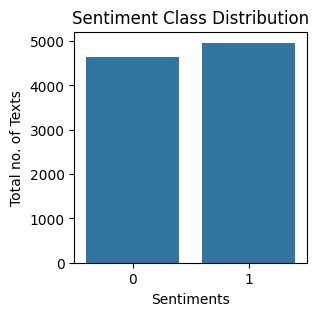

In [ ]:
file_path = "/content/drive/MyDrive/SST-2 (2 Classes).csv"
df = pd.read_csv(file_path, encoding='ISO-8859-1')
df = df[['Text', 'Sentiment']].dropna()
df.head()

total_instances = len(df)
print(f"Total instances: {total_instances}")

sentiment_counts = df['Sentiment'].value_counts()
print("Number of instances per sentiment:")
print(sentiment_counts)

plt.figure(figsize=(3,3))
sns.countplot(data=df, x='Sentiment')
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiments")
plt.ylabel("Total no. of Texts")
plt.grid(False)
plt.show()

### Preprocessing

In [ ]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Sentiment'])

print("Label Mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['Text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(f"Train size: {len(train_texts)}, Val size: {len(val_texts)}, Test size: {len(test_texts)}")

Label Mapping:
0: 0
1: 1
Train size: 7690, Val size: 961, Test size: 962


### Tokenization

In [ ]:
finetuned_model_name_1 = "distilbert-base-uncased-finetuned-sst-2-english"
finetuned_model_name_2 = "textattack/roberta-base-SST-2"

base_model_name_1 = "distilbert-base-uncased"
base_model_name_2 = "roberta-base"

tokenizer_1 = AutoTokenizer.from_pretrained(base_model_name_1)
tokenizer_2 = AutoTokenizer.from_pretrained(base_model_name_2)

train_encodings_1 = tokenizer_1(train_texts, truncation=True, padding=True, max_length=512)
val_encodings_1   = tokenizer_1(val_texts, truncation=True, padding=True, max_length=512)
test_encodings_1  = tokenizer_1(test_texts, truncation=True, padding=True, max_length=512)

train_encodings_2 = tokenizer_2(train_texts, truncation=True, padding=True, max_length=512)
val_encodings_2   = tokenizer_2(val_texts, truncation=True, padding=True, max_length=512)
test_encodings_2  = tokenizer_2(test_texts, truncation=True, padding=True, max_length=512)

### Dataset Class

In [ ]:
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()} | {'labels': torch.tensor(self.labels[idx])}

    def __len__(self):
        return len(self.labels)

train_dataset_1 = SentimentDataset(train_encodings_1, train_labels)
val_dataset_1   = SentimentDataset(val_encodings_1, val_labels)
test_dataset_1  = SentimentDataset(test_encodings_1, test_labels)

train_dataset_2 = SentimentDataset(train_encodings_2, train_labels)
val_dataset_2   = SentimentDataset(val_encodings_2, val_labels)
test_dataset_2  = SentimentDataset(test_encodings_2, test_labels)

### Utility Functions

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    proba = torch.softmax(torch.tensor(logits), dim=-1).numpy()

    acc = accuracy_score(labels, preds) * 100

    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")

    sims = []
    for i in range(len(labels)):
        true_onehot = np.zeros(proba.shape[1])
        true_onehot[labels[i]] = 1
        sims.append(cosine_similarity([true_onehot], [proba[i]])[0][0])
    similarity_score = np.mean(sims) * 100

    confidence_score = np.mean(np.max(proba, axis=1)) * 100

    return {
        "eval_Accuracy": acc,
        "eval_Precision": prec * 100,
        "eval_Recall": rec * 100,
        "eval_F1 Score": f1 * 100,
        "eval_Similarity Score": similarity_score,
        "eval_Confidence Score": confidence_score
    }

### Baseline Models Evaluation

In [ ]:
results = {}

print("=== BASELINE MODELS EVALUATION ===\n")

print("Evaluating Baseline DistilBERT...")
baseline_model_1 = AutoModelForSequenceClassification.from_pretrained(finetuned_model_name_1)
baseline_trainer_1 = Trainer(
    model=baseline_model_1,
    args=TrainingArguments(output_dir="./results", per_device_eval_batch_size=32, report_to="none"),
    eval_dataset=test_dataset_1,
    compute_metrics=compute_metrics
)
baseline_metrics_1 = baseline_trainer_1.evaluate()
results['baseline_distilbert'] = baseline_metrics_1

print("\n===== Performance of DistilBERT Model =====\n")
metrics_to_show = ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]
for metric in metrics_to_show:
    key = f"eval_{metric}"
    if key in baseline_metrics_1:
        print(f"{metric} is: {baseline_metrics_1[key]:.2f}%")

print("\nEvaluating Baseline RoBERTa...")
baseline_model_2 = AutoModelForSequenceClassification.from_pretrained(finetuned_model_name_2)
baseline_trainer_2 = Trainer(
    model=baseline_model_2,
    args=TrainingArguments(output_dir="./results", per_device_eval_batch_size=32, report_to="none"),
    eval_dataset=test_dataset_2,
    compute_metrics=compute_metrics
)
baseline_metrics_2 = baseline_trainer_2.evaluate()
results['baseline_roberta'] = baseline_metrics_2

print("\n===== Performance of RoBERTa Model =====\n")
for metric in metrics_to_show:
    key = f"eval_{metric}"
    if key in baseline_metrics_2:
        print(f"{metric} is: {baseline_metrics_2[key]:.2f}%")

=== BASELINE MODELS EVALUATION ===

Evaluating Baseline DistilBERT...


/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)



===== Performance of DistilBERT Model =====

Accuracy is: 98.13%
Precision is: 97.61%
Recall is: 98.79%
F1 Score is: 98.20%
Similarity Score is: 98.27%
Confidence Score is: 99.56%

Evaluating Baseline RoBERTa...


Some weights of the model checkpoint at textattack/roberta-base-SST-2 were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)



===== Performance of RoBERTa Model =====

Accuracy is: 97.51%
Precision is: 97.21%
Recall is: 97.99%
F1 Score is: 97.60%
Similarity Score is: 98.04%
Confidence Score is: 97.31%


### Baseline Confusion Matrices


=== BASELINE CONFUSION MATRICES ===


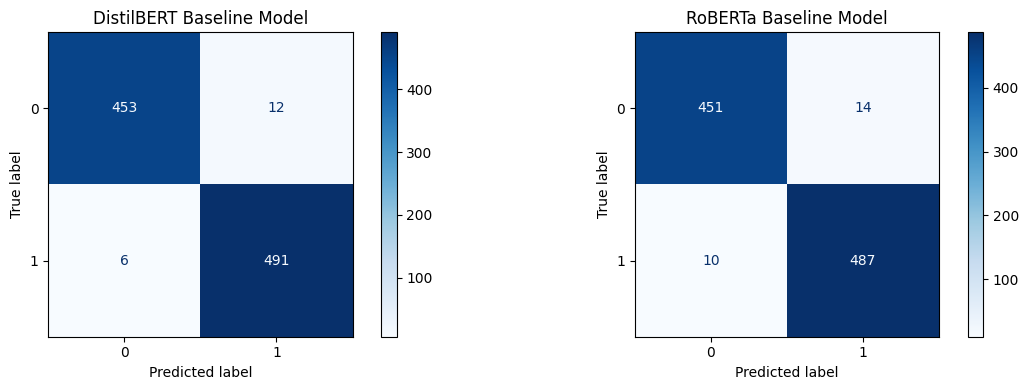

13384

In [ ]:
print("\n=== BASELINE CONFUSION MATRICES ===")
preds_1 = baseline_trainer_1.predict(test_dataset_1)
y_true_1 = preds_1.label_ids
y_pred_1 = preds_1.predictions.argmax(-1)

preds_2 = baseline_trainer_2.predict(test_dataset_2)
y_true_2 = preds_2.label_ids
y_pred_2 = preds_2.predictions.argmax(-1)

cm_1 = confusion_matrix(y_true_1, y_pred_1)
cm_2 = confusion_matrix(y_true_2, y_pred_2)

class_names = label_encoder.classes_

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_1, display_labels=class_names).plot(cmap="Blues", ax=ax1)
ax1.set_title("DistilBERT Baseline Model")
ConfusionMatrixDisplay(confusion_matrix=cm_2, display_labels=class_names).plot(cmap="Blues", ax=ax2)
ax2.set_title("RoBERTa Baseline Model")
plt.tight_layout()
plt.show()

del baseline_model_1, baseline_model_2, baseline_trainer_1, baseline_trainer_2
torch.cuda.empty_cache()
gc.collect()

### Fine-tuning BERT

In [ ]:
def get_gpu_memory():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / 1024**3
    return 0

print("=== FINE-TUNING DISTILBERT ===")
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
start_time = time.time()
config_1 = AutoConfig.from_pretrained(
    base_model_name_1,
    num_labels=len(label_encoder.classes_),
    hidden_dropout_prob=0.4,
    attention_probs_dropout_prob=0.3,
    classifier_dropout=0.3
)
model_base_1 = AutoModelForSequenceClassification.from_pretrained(
    base_model_name_1,
    config=config_1
)
total_params_before = sum(p.numel() for p in model_base_1.parameters())
trainable_params_before = sum(p.numel() for p in model_base_1.parameters() if p.requires_grad)
training_args_1 = TrainingArguments(
    output_dir="./results_1",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.2,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_strategy="epoch",
    report_to="none",
    fp16=True,
    gradient_accumulation_steps=1,
    save_total_limit=2,
    max_grad_norm=1.0,
    lr_scheduler_type="linear",
    seed=42,
    dataloader_pin_memory=False,
)
trainer_base_1 = Trainer(
    model=model_base_1,
    args=training_args_1,
    train_dataset=train_dataset_1,
    eval_dataset=val_dataset_1,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=3),
    ]
)
trainer_base_1.train()
training_time_1 = time.time() - start_time
gpu_memory_1 = get_gpu_memory()
finetuned_metrics_1 = trainer_base_1.evaluate(test_dataset_1)
results['finetuned_distilbert'] = {
    **finetuned_metrics_1,
    'training_time': training_time_1,
    'total_parameters': total_params_before,
    'trainable_parameters': trainable_params_before,
    'gpu_memory_gb': gpu_memory_1
}

print("=== FINE-TUNING ROBERTA ===")
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
start_time = time.time()
config_2 = AutoConfig.from_pretrained(
    base_model_name_2,
    num_labels=len(label_encoder.classes_),
    hidden_dropout_prob=0.4,
    attention_probs_dropout_prob=0.3,
    classifier_dropout=0.3
)
model_base_2 = AutoModelForSequenceClassification.from_pretrained(
    base_model_name_2,
    config=config_2
)
total_params_before_2 = sum(p.numel() for p in model_base_2.parameters())
trainable_params_before_2 = sum(p.numel() for p in model_base_2.parameters() if p.requires_grad)
training_args_2 = TrainingArguments(
    output_dir="./results_2",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    weight_decay=0.2,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_strategy="epoch",
    report_to="none",
    fp16=True,
    gradient_accumulation_steps=1,
    save_total_limit=2,
    max_grad_norm=1.0,
    lr_scheduler_type="linear",
    seed=42,
    dataloader_pin_memory=False,
)
trainer_base_2 = Trainer(
    model=model_base_2,
    args=training_args_2,
    train_dataset=train_dataset_2,
    eval_dataset=val_dataset_2,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=3),
    ]
)
trainer_base_2.train()
training_time_2 = time.time() - start_time
gpu_memory_2 = get_gpu_memory()
finetuned_metrics_2 = trainer_base_2.evaluate(test_dataset_2)
results['finetuned_roberta'] = {
    **finetuned_metrics_2,
    'training_time': training_time_2,
    'total_parameters': total_params_before_2,
    'trainable_parameters': trainable_params_before_2,
    'gpu_memory_gb': gpu_memory_2
}

=== FINE-TUNING DISTILBERT ===


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated.

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score,Similarity score,Confidence score
1,0.457800,0.377050,85.015609,80.136986,94.354839,86.666667,87.487682,89.912178
2,0.238900,0.321556,88.657648,86.857143,91.935484,89.324192,90.148133,95.126274
3,0.128400,0.415071,90.114464,91.340206,89.314516,90.316004,90.517894,98.362602
4,0.059700,0.513260,89.698231,89.306931,90.927419,90.109890,90.304248,98.702217
5,0.027800,0.582247,90.218522,90.524194,90.524194,90.524194,90.738182,99.010239


=== FINE-TUNING ROBERTA ===


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is dep

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score,Similarity score,Confidence score
1,0.698400,0.691265,51.612903,51.612903,100.000000,68.085106,70.843225,52.098484
2,0.696600,0.682357,51.612903,51.612903,100.000000,68.085106,71.462493,53.883617
3,0.616600,0.484707,78.355879,70.930233,98.387097,82.432432,82.169483,75.810883
4,0.528700,0.295511,87.825182,83.187391,95.766129,89.034677,90.292810,87.567581
5,0.459700,0.262863,88.969823,85.198556,95.161290,89.904762,91.207659,90.100746
6,0.437000,0.285570,89.073881,84.848485,95.967742,90.066225,90.709283,91.918327
7,0.428300,0.300227,88.241415,83.893805,95.564516,89.349670,90.449646,93.437614
8,0.407100,0.288526,88.553590,84.837545,94.758065,89.523810,90.800501,93.676262


### Fine-tuned Confusion Matrices


=== FINE-TUNED CONFUSION MATRICES ===


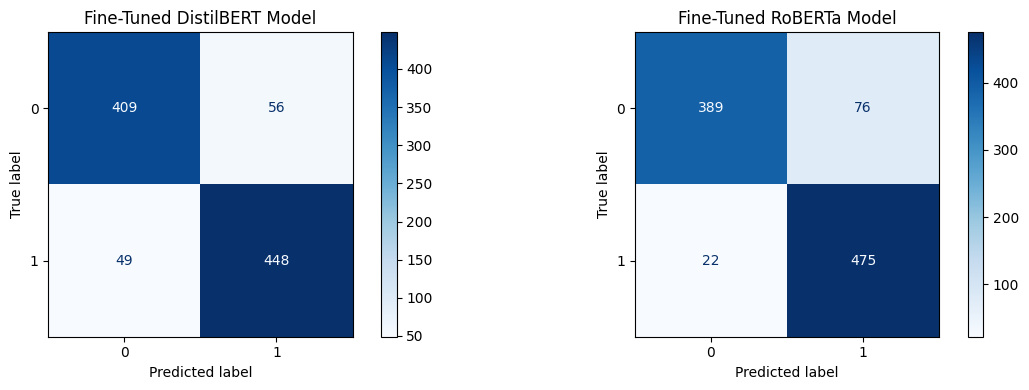

In [ ]:
print("\n=== FINE-TUNED CONFUSION MATRICES ===")
preds_1 = trainer_base_1.predict(test_dataset_1)
y_true_1 = preds_1.label_ids
y_pred_1 = preds_1.predictions.argmax(-1)

preds_2 = trainer_base_2.predict(test_dataset_2)
y_true_2 = preds_2.label_ids
y_pred_2 = preds_2.predictions.argmax(-1)

cm_1 = confusion_matrix(y_true_1, y_pred_1)
cm_2 = confusion_matrix(y_true_2, y_pred_2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_1, display_labels=class_names).plot(cmap="Blues", ax=ax1)
ax1.set_title("Fine-Tuned DistilBERT Model")
ConfusionMatrixDisplay(confusion_matrix=cm_2, display_labels=class_names).plot(cmap="Blues", ax=ax2)
ax2.set_title("Fine-Tuned RoBERTa Model")
plt.tight_layout()
plt.show()

### Fine-tuned Training and Validation loss

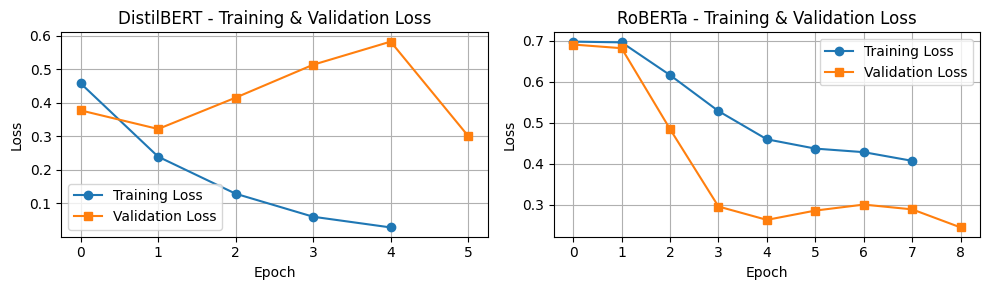

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

train_loss_1 = [log['loss'] for log in trainer_base_1.state.log_history if 'loss' in log and 'eval_loss' not in log]
eval_loss_1 = [log['eval_loss'] for log in trainer_base_1.state.log_history if 'eval_loss' in log]

ax1.plot(train_loss_1, label='Training Loss', marker="o")
ax1.plot(eval_loss_1, label='Validation Loss', marker="s")
ax1.set_title('DistilBERT - Training & Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

train_loss_2 = [log['loss'] for log in trainer_base_2.state.log_history if 'loss' in log and 'eval_loss' not in log]
eval_loss_2 = [log['eval_loss'] for log in trainer_base_2.state.log_history if 'eval_loss' in log]

ax2.plot(train_loss_2, label='Training Loss', marker="o")
ax2.plot(eval_loss_2, label='Validation Loss', marker="s")
ax2.set_title('RoBERTa - Training & Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
del model_base_1, model_base_2, trainer_base_1, trainer_base_2
torch.cuda.empty_cache()
gc.collect()

23812

### Adapter (LoRA) BERT

In [ ]:
print("=== ADAPTER (LoRA) DISTILBERT ===")
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
start_time = time.time()
adapter_model_1 = AutoModelForSequenceClassification.from_pretrained(
    base_model_name_1,
    num_labels=len(label_encoder.classes_)
)
peft_config_1 = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=6,
    lora_alpha=12,
    lora_dropout=0.2,
    target_modules=["q_lin", "v_lin", "out_lin"],
    bias="none",
    modules_to_save=["classifier"]
)
adapter_model_1 = get_peft_model(adapter_model_1, peft_config_1)
adapter_model_1.print_trainable_parameters()
adapter_args_1 = TrainingArguments(
    output_dir="./results-adapter-1",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.05,
    warmup_ratio=0.1,
    logging_dir="./logs-adapter-1",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    seed=42,
    fp16=True,
    gradient_accumulation_steps=1,
    max_grad_norm=1.0,
    save_total_limit=2,
    lr_scheduler_type="cosine",
    dataloader_pin_memory=False,
    remove_unused_columns=True
)
trainer_adapter_1 = Trainer(
    model=adapter_model_1,
    args=adapter_args_1,
    train_dataset=train_dataset_1,
    eval_dataset=val_dataset_1,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=3),
    ]
)
trainer_adapter_1.train()
training_time_lora_1 = time.time() - start_time
gpu_memory_lora_1 = get_gpu_memory()
adapter_metrics_1 = trainer_adapter_1.evaluate(test_dataset_1)
results['adapter_distilbert'] = {
    **adapter_metrics_1,
    'training_time': training_time_lora_1,
    'total_parameters': sum(p.numel() for p in adapter_model_1.parameters()),
    'trainable_parameters': sum(p.numel() for p in adapter_model_1.parameters() if p.requires_grad),
    'gpu_memory_gb': gpu_memory_lora_1
}

print("=== ADAPTER (LoRA) ROBERTA ===")
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
start_time = time.time()
adapter_model_2 = AutoModelForSequenceClassification.from_pretrained(
    base_model_name_2,
    num_labels=len(label_encoder.classes_)
)
peft_config_2 = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=6,
    lora_alpha=12,
    lora_dropout=0.2,
    target_modules=["query", "value", "output.dense"],
    bias="none",
    modules_to_save=["classifier"]
)
adapter_model_2 = get_peft_model(adapter_model_2, peft_config_2)
adapter_model_2.print_trainable_parameters()
adapter_args_2 = TrainingArguments(
    output_dir="./results-adapter-2",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.05,
    warmup_ratio=0.1,
    logging_dir="./logs-adapter-2",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    seed=42,
    fp16=True,
    gradient_accumulation_steps=1,
    max_grad_norm=1.0,
    save_total_limit=2,
    lr_scheduler_type="cosine",
    dataloader_pin_memory=False,
    remove_unused_columns=True
)
trainer_adapter_2 = Trainer(
    model=adapter_model_2,
    args=adapter_args_2,
    train_dataset=train_dataset_2,
    eval_dataset=val_dataset_2,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=3),
    ]
)
trainer_adapter_2.train()
training_time_lora_2 = time.time() - start_time
gpu_memory_lora_2 = get_gpu_memory()
adapter_metrics_2 = trainer_adapter_2.evaluate(test_dataset_2)
results['adapter_roberta'] = {
    **adapter_metrics_2,
    'training_time': training_time_lora_2,
    'total_parameters': sum(p.numel() for p in adapter_model_2.parameters()),
    'trainable_parameters': sum(p.numel() for p in adapter_model_2.parameters() if p.requires_grad),
    'gpu_memory_gb': gpu_memory_lora_2
}

=== ADAPTER (LoRA) DISTILBERT ===


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


trainable params: 758,018 || all params: 67,713,028 || trainable%: 1.1195


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score,Similarity score,Confidence score
1,0.422800,0.336414,86.056191,84.807692,88.911290,86.811024,88.702817,91.695114
2,0.314200,0.293249,88.449532,87.671233,90.322581,88.977160,90.432507,92.818466
3,0.250400,0.356235,88.865765,88.667992,89.919355,89.289289,90.262962,96.060074
4,0.215700,0.410520,88.865765,86.355140,93.145161,89.621726,89.881261,96.094933
5,0.179100,0.430367,89.386056,89.878543,89.516129,89.696970,90.241080,97.391792


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in ver

=== ADAPTER (LoRA) ROBERTA ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


trainable params: 1,200,386 || all params: 125,847,556 || trainable%: 0.9538


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score,Similarity score,Confidence score
1,0.416900,0.251413,91.883455,91.468254,92.943548,92.200000,92.789380,93.533257
2,0.254800,0.313832,91.675338,92.448980,91.330645,91.886410,92.268570,98.403397
3,0.189300,0.319817,91.675338,91.935484,91.935484,91.935484,92.312048,98.604546
4,0.162800,0.434389,90.634755,86.642599,96.774194,91.428571,91.067936,98.633362


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in ver

In [ ]:
print(f"DistilBERT Predictions: {np.unique(y_pred_1)}")
print(f"RoBERTa Predictions: {np.unique(y_pred_2)}")

DistilBERT Predictions: [0 1]
RoBERTa Predictions: [0 1]


### Adapter Confusion Matrices


=== ADAPTER CONFUSION MATRICES ===


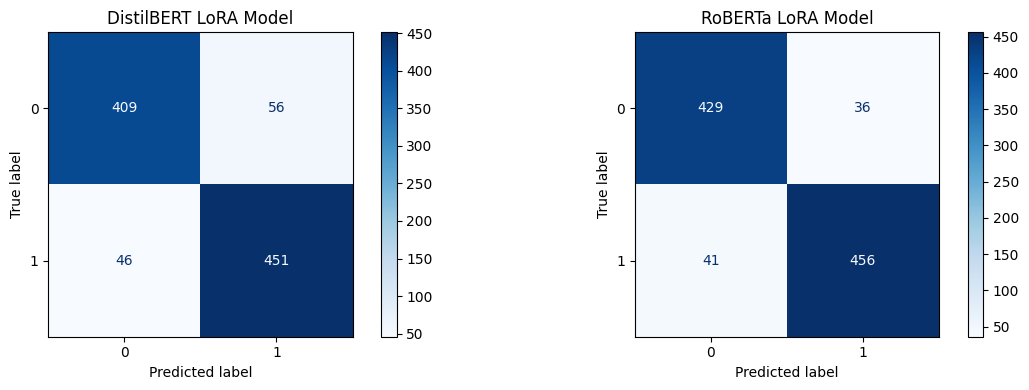

In [ ]:
print("\n=== ADAPTER CONFUSION MATRICES ===")
preds_1 = trainer_adapter_1.predict(test_dataset_1)
y_true_1, y_pred_1 = preds_1.label_ids, preds_1.predictions.argmax(-1)

preds_2 = trainer_adapter_2.predict(test_dataset_2)
y_true_2, y_pred_2 = preds_2.label_ids, preds_2.predictions.argmax(-1)

cm_1 = confusion_matrix(y_true_1, y_pred_1)
cm_2 = confusion_matrix(y_true_2, y_pred_2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_1, display_labels=class_names).plot(cmap="Blues", ax=ax1)
ax1.set_title("DistilBERT LoRA Model")
ConfusionMatrixDisplay(confusion_matrix=cm_2, display_labels=class_names).plot(cmap="Blues", ax=ax2)
ax2.set_title("RoBERTa LoRA Model")
plt.tight_layout()
plt.show()

### Adapter Confusion Training & Validation loss

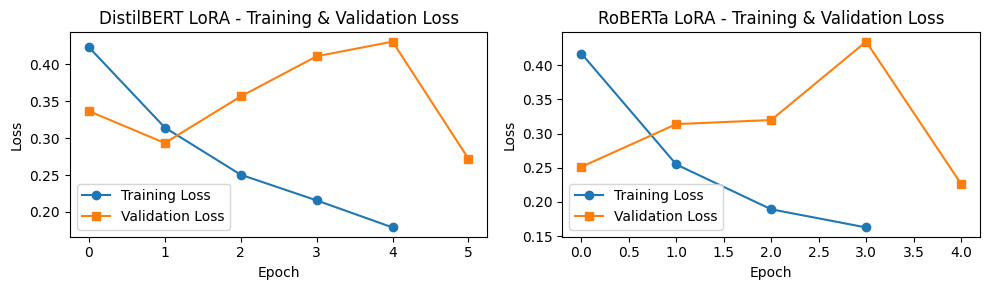

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

train_loss_1 = [log['loss'] for log in trainer_adapter_1.state.log_history if 'loss' in log and 'eval_loss' not in log]
eval_loss_1 = [log['eval_loss'] for log in trainer_adapter_1.state.log_history if 'eval_loss' in log]

ax1.plot(train_loss_1, label='Training Loss', marker="o")
ax1.plot(eval_loss_1, label='Validation Loss', marker="s")
ax1.set_title('DistilBERT LoRA - Training & Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(False)

train_loss_2 = [log['loss'] for log in trainer_adapter_2.state.log_history if 'loss' in log and 'eval_loss' not in log]
eval_loss_2 = [log['eval_loss'] for log in trainer_adapter_2.state.log_history if 'eval_loss' in log]

ax2.plot(train_loss_2, label='Training Loss', marker="o")
ax2.plot(eval_loss_2, label='Validation Loss', marker="s")
ax2.set_title('RoBERTa LoRA - Training & Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(False)

plt.tight_layout()
plt.show()

### Comprehensive Comparison Table

In [ ]:
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

comparison_data = []

models = [
    ('Baseline DistilBERT', 'baseline_distilbert'),
    ('Fine-Tuned DistilBERT', 'finetuned_distilbert'),
    ('Adapter DistilBERT', 'adapter_distilbert'),
    ('Baseline RoBERTa', 'baseline_roberta'),
    ('Fine-Tuned RoBERTa', 'finetuned_roberta'),
    ('Adapter RoBERTa', 'adapter_roberta')
]

for model_name, model_key in models:
    if model_key in results:
        metrics = results[model_key]
        row = {
            'Model': model_name,
            'Accuracy': metrics.get('eval_Accuracy', 0),
            'Precision': metrics.get('eval_Precision', 0),
            'Recall': metrics.get('eval_Recall', 0),
            'F1 Score': metrics.get('eval_F1 Score', 0),
            'Similarity': metrics.get('eval_Similarity Score', 0),
            'Confidence': metrics.get('eval_Confidence Score', 0),
            'Training Time (s)': metrics.get('training_time', 'N/A'),
            'Trainable Params': metrics.get('trainable_parameters', 'N/A'),
            'GPU Memory (GB)': metrics.get('gpu_memory_gb', 'N/A')
        }
        comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)

numeric_columns = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Similarity', 'Confidence']
for col in numeric_columns:
    comparison_df[col] = comparison_df[col].apply(lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else x)

print("\nCOMPREHENSIVE COMPARISON TABLE:")
print(comparison_df.to_string(index=False))


COMPREHENSIVE MODEL COMPARISON

COMPREHENSIVE COMPARISON TABLE:
                Model Accuracy Precision Recall F1 Score Similarity Confidence Training Time (s) Trainable Params GPU Memory (GB)
  Baseline DistilBERT    98.13     97.61  98.79    98.20      98.27      99.56               N/A              N/A             N/A
Fine-Tuned DistilBERT    89.09     88.89  90.14    89.51      90.83      95.01        209.500994         66955010         2.03103
   Adapter DistilBERT    89.40     88.95  90.74    89.84      91.28      93.05         175.88085           758018        1.013465
     Baseline RoBERTa    97.51     97.21  97.99    97.60      98.04      97.31               N/A              N/A             N/A
   Fine-Tuned RoBERTa    89.81     86.21  95.57    90.65      92.08      90.26        610.177522        124647170        3.872342
      Adapter RoBERTa    92.00     92.68  91.75    92.21      93.31      93.45        305.415961          1200386        1.230187


### Performance Visualization


PERFORMANCE COMPARISON: Pretrained vs Fine-Tuned vs Adapter (LoRA)


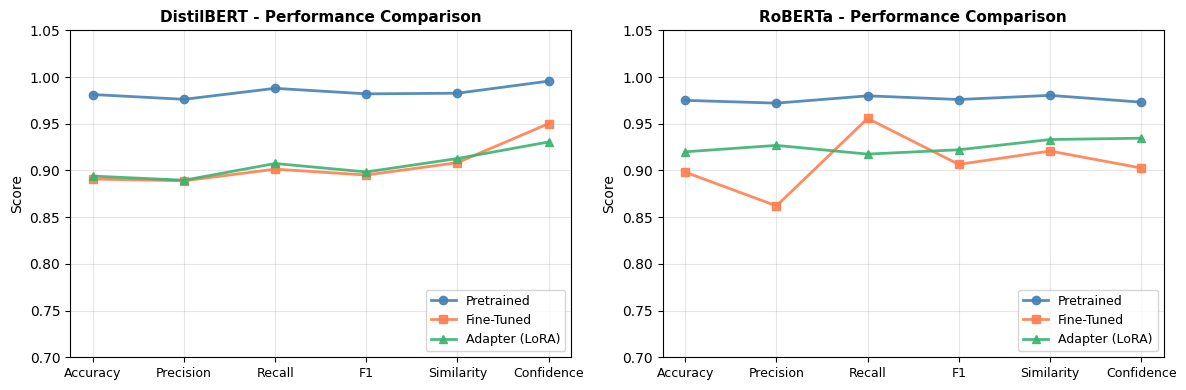

In [ ]:
print("\n" + "="*80)
print("PERFORMANCE COMPARISON: Pretrained vs Fine-Tuned vs Adapter (LoRA)")
print("="*80)

metrics = ["Accuracy", "Precision", "Recall", "F1", "Similarity", "Confidence"]

# DistilBERT metrics
pretrained_vals_1 = np.array([baseline_metrics_1[f"eval_{m}"] for m in ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]]) / 100
base_vals_1 = np.array([finetuned_metrics_1[f"eval_{m}"] for m in ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]]) / 100
adapter_vals_1 = np.array([adapter_metrics_1[f"eval_{m}"] for m in ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]]) / 100

# RoBERTa metrics
pretrained_vals_2 = np.array([baseline_metrics_2[f"eval_{m}"] for m in ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]]) / 100
base_vals_2 = np.array([finetuned_metrics_2[f"eval_{m}"] for m in ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]]) / 100
adapter_vals_2 = np.array([adapter_metrics_2[f"eval_{m}"] for m in ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]]) / 100

x = np.arange(len(metrics))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(x, pretrained_vals_1, marker='o', linestyle='-', linewidth=2, alpha=0.9, label="Pretrained", color='steelblue')
ax1.plot(x, base_vals_1, marker='s', linestyle='-', linewidth=2, alpha=0.9, label="Fine-Tuned", color='coral')
ax1.plot(x, adapter_vals_1, marker='^', linestyle='-', linewidth=2, alpha=0.9, label="Adapter (LoRA)", color='mediumseagreen')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=9)
ax1.set_ylabel("Score", fontsize=10)
ax1.set_ylim(0.70, 1.05)
ax1.set_title("DistilBERT - Performance Comparison", fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc="lower right", fontsize=9)

ax2.plot(x, pretrained_vals_2, marker='o', linestyle='-', linewidth=2, alpha=0.9, label="Pretrained", color='steelblue')
ax2.plot(x, base_vals_2, marker='s', linestyle='-', linewidth=2, alpha=0.9, label="Fine-Tuned", color='coral')
ax2.plot(x, adapter_vals_2, marker='^', linestyle='-', linewidth=2, alpha=0.9, label="Adapter (LoRA)", color='mediumseagreen')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics, fontsize=9)
ax2.set_ylabel("Score", fontsize=10)
ax2.set_ylim(0.70, 1.05)
ax2.set_title("RoBERTa - Performance Comparison", fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

### Resource Usage Comparison

In [ ]:
print("\n" + "="*50)
print("RESOURCE USAGE COMPARISON")
print("="*50)

# Extract data
distilbert_ft = results['finetuned_distilbert']
distilbert_ad = results['adapter_distilbert']
roberta_ft = results['finetuned_roberta']
roberta_ad = results['adapter_roberta']

# DistilBERT Table
print("\n" + "DISTILBERT - RESOURCE USAGE".center(40))
print("-" * 40)
print(f"{'Metric':<20} {'Fine-Tuned':<12} {'Adapter':<12}")
print("-" * 40)
print(f"{'Training Time (s)':<20} {distilbert_ft['training_time']:<12.0f} {distilbert_ad['training_time']:<12.0f}")
print(f"{'Trainable Params':<20} {distilbert_ft['trainable_parameters']:<12,} {distilbert_ad['trainable_parameters']:<12,}")
print(f"{'GPU Memory (GB)':<20} {distilbert_ft['gpu_memory_gb']:<12.2f} {distilbert_ad['gpu_memory_gb']:<12.2f}")
print("-" * 40)

# RoBERTa Table
print("\n" + "ROBERTA - RESOURCE USAGE".center(40))
print("-" * 40)
print(f"{'Metric':<20} {'Fine-Tuned':<12} {'Adapter':<12}")
print("-" * 40)
print(f"{'Training Time (s)':<20} {roberta_ft['training_time']:<12.0f} {roberta_ad['training_time']:<12.0f}")
print(f"{'Trainable Params':<20} {roberta_ft['trainable_parameters']:<12,} {roberta_ad['trainable_parameters']:<12,}")
print(f"{'GPU Memory (GB)':<20} {roberta_ft['gpu_memory_gb']:<12.2f} {roberta_ad['gpu_memory_gb']:<12.2f}")
print("-" * 40)


RESOURCE USAGE COMPARISON

      DISTILBERT - RESOURCE USAGE       
----------------------------------------
Metric               Fine-Tuned   Adapter     
----------------------------------------
Training Time (s)    210          176         
Trainable Params     66,955,010   758,018     
GPU Memory (GB)      2.03         1.01        
----------------------------------------

        ROBERTA - RESOURCE USAGE        
----------------------------------------
Metric               Fine-Tuned   Adapter     
----------------------------------------
Training Time (s)    610          305         
Trainable Params     124,647,170  1,200,386   
GPU Memory (GB)      3.87         1.23        
----------------------------------------
